In [1]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import torch.nn.functional as F

In [68]:
words = open('names.txt', 'r').read().splitlines()

In [69]:
chars = sorted(list(set(''.join(words))))

stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [70]:
block_size = 3

def build_dataset(words):
  block_size = 3
  X, Y = [], []

  for w in words:
      context = [0] * block_size
      for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '-->', itos[ix])
        context = context[1:] + [ix]
  
  X = torch.tensor(X)
  Y = torch.tensor(Y)

  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset (words[n2:])

In [88]:
g = torch.Generator().manual_seed(2147483647)
vocab_size = 27
n_emb = 10
n_hidden = 200

C = torch.randn(vocab_size, n_emb)
W1 = torch.randn(n_emb * block_size, n_hidden).float() * (5/3)/((n_emb * block_size)**0.5)
b1 = torch.randn(n_hidden).float() * 0.01
W2 = torch.randn(n_hidden, vocab_size).float() * 0.01
b2 = torch.randn(vocab_size).float() * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden)) 
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

params = [C, W1, b1, W2, b2, bngain, bnbias]

print(sum([p.nelement() for p in params]))

for p in params:
  p.requires_grad = True

12297


In [89]:
max_steps = 100000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # mini-batch construct
  ix = torch.randint(0, Xtr.shape[0], (32,)) # random 32 numbersin range from 0 to Xtr.shape[0] (182625)
  Xb, Yb = Xtr[ix], Ytr[ix] # X, Y batch

  # forward
  emb = C[Xb] # 32, 3, 2
  embcat = emb.view(emb.shape[0], -1)
  # Linear Layer
  hpreact = embcat @ W1 + b1  
  # BatchNorm
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  
  h = torch.tanh(hpreact) # hidden-layer (activation)                  
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb)

  # backward
  for p in params:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 40000 else 0.01 
  for p in params:
    p.data += -lr * p.grad

  # tracking
  if i % 10000 == 0:
    print(f'{i:6d}/{max_steps:7d}: {loss.item():.5f}')
  lossi.append(loss.item())
  
  # break



     0/ 100000: 3.30562
 10000/ 100000: 2.79857
 20000/ 100000: 1.82649
 30000/ 100000: 2.41560
 40000/ 100000: 2.23361
 50000/ 100000: 2.10400
 60000/ 100000: 2.13809
 70000/ 100000: 1.93412
 80000/ 100000: 2.58475
 90000/ 100000: 1.82229


In [94]:
emb = C[Xb] # 32, 3, 2
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1  
h = torch.tanh(hpreact) # hidden-layer                     
logits = h @ W2 + b2 # output layer
loss = F.cross_entropy(logits, Yb)
loss

tensor(3.4589, grad_fn=<NllLossBackward0>)

In [53]:
hpreact.mean(0, keepdim=True).shape, hpreact.std(0, keepdim=True).shape

(torch.Size([1, 200]), torch.Size([1, 200]))

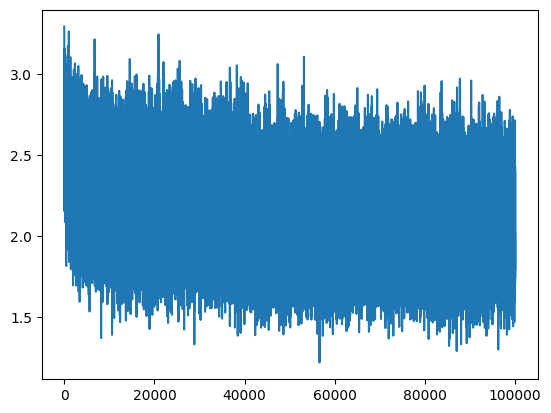

In [14]:
plt.plot(lossi);

In [ ]:
# sampling

block_size = 3
g = torch.Generator().manual_seed(2147483647 + 11)

for _ in range(30):
  out = []
  context = [0] * block_size

  while True:
    emb = C[torch.tensor([context])]
    h = torch.tanh(emb.view(1, -1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)

    if ix == 0:
      break

  print(''.join(itos[i] for i in out))

